Used claude.ai for most of this code lol

An extremely general way to do Z2 symmetry, aka (f(x) = f(-x)), is to just symmetrize. You can find the symmetric part of a matrix by defining a new matrix M_s(x) = 1/2[M(x) + M(-x)]. You can see M_s(-x) = 1/2(M(-x) + M(-x)) = M_s.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#neural net
class NeuralNet(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

#same but symmetrize
class SymmetricNet(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.g = NeuralNet(hidden_dim=hidden_dim)
    def forward(self, x):
        return 0.5 * (self.g(x) + self.g(-x))


In [3]:
def make_dataset(fn, n=20, x_range=(-3, 3), noise=0.05):
    x = torch.FloatTensor(n, 1).uniform_(*x_range)
    y = fn(x) + noise * torch.randn(n, 1)
    return x, y

even_fn    = lambda x: x**2 + torch.cos(x)          # symmetric
broken_fn  = lambda x: x**3 + x + 1.0               # Not symmetric


In [4]:
def train(model, x, y, epochs=2000, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses = []
    for _ in range(epochs):
        pred = model(x)
        loss = loss_fn(pred, y)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return losses

def eval_mse(model, x, y):
    with torch.no_grad():
        return nn.MSELoss()(model(x), y).item()

In [5]:
results = {}
for name, fn in [("Z2 Symmetric  f=x²+cos(x)", even_fn),
                 ("Z2 Broken  f=x³+x+1",        broken_fn)]:
    x_train, y_train = make_dataset(fn, n=500)
    x_test,  y_test  = make_dataset(fn, n=200)

    baseline  = NeuralNet()
    symmetric = SymmetricNet()

    torch.manual_seed(42)
    baseline  = NeuralNet();        l_base = train(baseline,  x_train, y_train)
    torch.manual_seed(42)
    symmetric = SymmetricNet(); l_sym = train(symmetric, x_train, y_train)

    results[name] = {
        "baseline_test_mse":  eval_mse(baseline,  x_test, y_test),
        "symmetric_test_mse": eval_mse(symmetric, x_test, y_test),
        "loss_base": l_base,
        "loss_sym":  l_sym,
        "x_test": x_test, "y_test": y_test,
        "baseline_model": baseline,
        "symmetric_model": symmetric,
        "fn": fn
    }



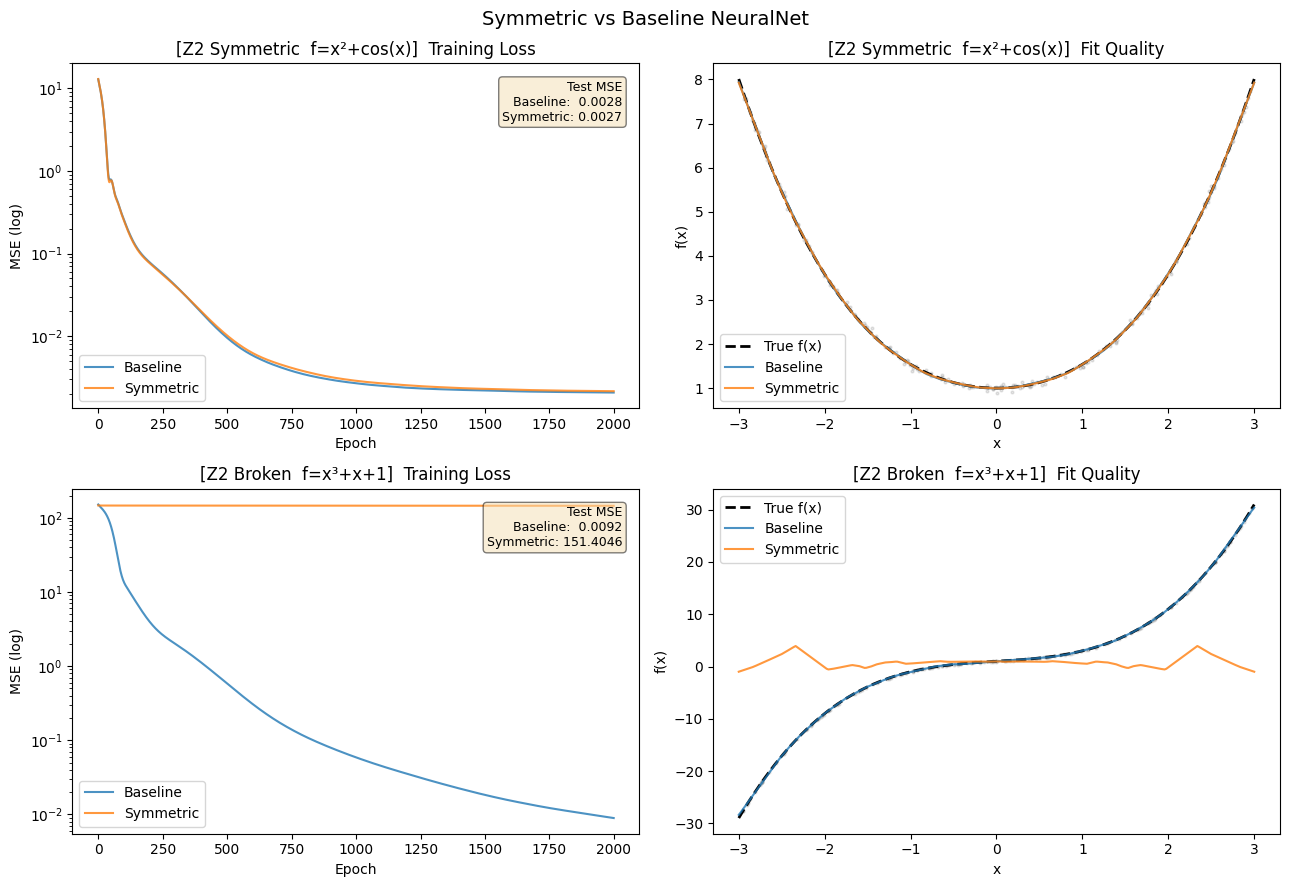


===  Results  ===

Z2 Symmetric  f=x²+cos(x)
  Baseline  test MSE : 0.00278
  Symmetric test MSE : 0.00269
  Winner: Symmetric ✓  (Δ = 0.00009)

Z2 Broken  f=x³+x+1
  Baseline  test MSE : 0.00921
  Symmetric test MSE : 151.40460
  Winner: Baseline ✓  (Δ = 151.39539)


In [6]:
# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Symmetric vs Baseline NeuralNet", fontsize=14)

x_plot = torch.linspace(-3, 3, 300).unsqueeze(1)

for row, (name, res) in enumerate(results.items()):
    # Left: training curves
    ax = axes[row, 0]
    ax.plot(res["loss_base"], label="Baseline",  alpha=0.8)
    ax.plot(res["loss_sym"],  label="Symmetric", alpha=0.8)
    ax.set_yscale("log")
    ax.set_title(f"[{name}]  Training Loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (log)"); ax.legend()
    ax.text(0.97, 0.95,
        f"Test MSE\nBaseline:  {res['baseline_test_mse']:.4f}\nSymmetric: {res['symmetric_test_mse']:.4f}",
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=9)

    # Right: fit quality
    ax = axes[row, 1]
    with torch.no_grad():
        y_true = res["fn"](x_plot)
        y_base = res["baseline_model"](x_plot)
        y_sym  = res["symmetric_model"](x_plot)

    ax.plot(x_plot, y_true, 'k--',  label="True f(x)",  linewidth=2)
    ax.plot(x_plot, y_base, label="Baseline",  alpha=0.8)
    ax.plot(x_plot, y_sym,  label="Symmetric", alpha=0.8)
    ax.scatter(res["x_test"], res["y_test"], s=4, alpha=0.2, c='gray')
    ax.set_title(f"[{name}]  Fit Quality")
    ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.legend()

plt.tight_layout()
#plt.savefig("z2_experiment.png", dpi=150)
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n===  Results  ===")
for name, res in results.items():
    b, s = res["baseline_test_mse"], res["symmetric_test_mse"]
    winner = "Symmetric ✓" if s < b else "Baseline ✓"
    print(f"\n{name}")
    print(f"  Baseline  test MSE : {b:.5f}")
    print(f"  Symmetric test MSE : {s:.5f}")
    print(f"  Winner: {winner}  (Δ = {abs(b-s):.5f})")

For this simple result the symmetric is barely better, but fully 100% fails for the non symmetric case. cool! Maybe it would do better for a more complex symmetry or a stronger  function

The symmetry architecture actually does much much better. But i wonder how important the mass error is because this only works because our data is restricted to not dissapear over the boundaries. The constrained model learns faster too!